In [ ]:
import sys
import yaml
import argparse
import numpy as np
import igraph as ig
import networkx as nx
from qlgates.config import Config
from qlgates.run_dynamics import propagate_state, build_unitary, bell_state
from qlgates.qlgraphs import qldit, cart_qldit

In [15]:
print(sys.executable)   # should show your conda env path, not system python

"""Load YAML and merge into Config dataclass."""
with open("../configs/bellstates.yaml") as f:
    overrides = yaml.safe_load(f)  # plain dict from YAML

# These are computed in __post_init__, never let YAML set them
overrides.pop("l", None)
overrides.pop("lp", None)

# Create Config instance with merged parameters
cfg = Config(**overrides)

/Users/sahadebadrita/opt/anaconda3/envs/graphs/bin/python


In [23]:
#Create QL-resources -- QL-bits, Cartesian Products
qlbit_1 = qldit(cfg.n, cfg.k, cfg.l, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
qlbit_2 = qldit(cfg.n, cfg.k, cfg.lp, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
qlbit1_qlbit2 = cart_qldit(qlbit_1,qlbit_2)

#eigenstates of the composite system
cart_eigvals, cart_eigvecs = np.linalg.eigh(qlbit1_qlbit2)

In [34]:
#Generate all four Bell states
psi0 = cart_eigvecs[:,-1]  # largest state of the composite system is the |00> state, which is the reference state for generating Bell states

bellstate_phi_minus = bell_state(cfg, psi0, kind="phi_minus")
bellstate_phi_plus = bell_state(cfg, psi0, kind="phi_plus")
bellstate_psi_minus = bell_state(cfg, psi0, kind="psi_minus")
bellstate_psi_plus = bell_state(cfg, psi0, kind="psi_plus")

In [35]:
for i in range(4):
    print('bellstate_phi_plus:', np.vdot(bellstate_phi_plus, cart_eigvecs[:,-(i+1)]))
for i in range(4):    
    print('bellstate_phi_minus:', np.vdot(bellstate_phi_minus, cart_eigvecs[:,-(i+1)]))
for i in range(4):    
    print('bellstate_psi_plus:', np.vdot(bellstate_psi_plus, cart_eigvecs[:,-(i+1)]))
for i in range(4):    
    print('bellstate_psi_minus:', np.vdot(bellstate_psi_minus, cart_eigvecs[:,-(i+1)]))

bellstate_phi_plus: (0.7071067811865521+0j)
bellstate_phi_plus: (2.9680034471790684e-16+0j)
bellstate_phi_plus: (3.984442983884229e-16+0j)
bellstate_phi_plus: (0.7071067811865517+0j)
bellstate_phi_minus: (0.7071067811865522+0j)
bellstate_phi_minus: (2.943066797211902e-16+0j)
bellstate_phi_minus: (1.143833291972207e-17+0j)
bellstate_phi_minus: (-0.7071067811865519+0j)
bellstate_psi_plus: (-8.960930955592694e-17+0j)
bellstate_psi_plus: (-0.7071067811865525+0j)
bellstate_psi_plus: (-0.7071067811865521+0j)
bellstate_psi_plus: (-1.507583120841094e-16+0j)
bellstate_psi_minus: (1.0446287931897835e-16+0j)
bellstate_psi_minus: (-0.7071067811865519+0j)
bellstate_psi_minus: (0.7071067811865526+0j)
bellstate_psi_minus: (6.239583502654078e-16+0j)


In [38]:
nsamples = 100
pdist = np.zeros((nsamples, 4), dtype=complex)
for i in range(nsamples):
    #Create QL-resources -- QL-bits, Cartesian Products
    qlbit_1 = qldit(cfg.n, cfg.k, cfg.l, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
    qlbit_2 = qldit(cfg.n, cfg.k, cfg.lp, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
    qlbit1_qlbit2 = cart_qldit(qlbit_1,qlbit_2)

    #eigenstates of the composite system
    cart_eigvals, cart_eigvecs = np.linalg.eigh(qlbit1_qlbit2)

    bellstate_psi_plus = bell_state(cfg, cart_eigvecs[:,-1], kind="psi_plus")
    for j in range(4): 
        pdist[i,j] = np.vdot(bellstate_psi_plus, cart_eigvecs[:,-(j+1)])

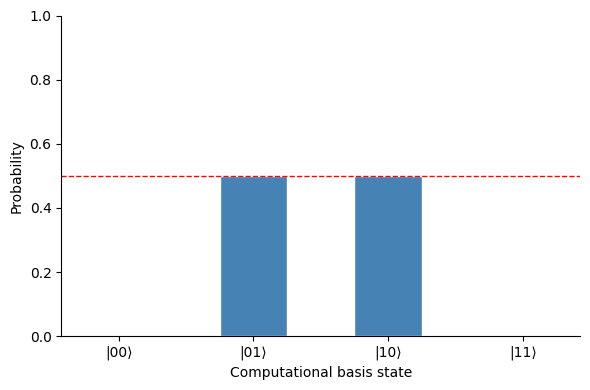

In [43]:
import matplotlib.pyplot as plt

basis_labels = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]
data = np.abs(pdist)**2   # shape (100, 4)
# average probability across all 100 rows for each basis state
mean_probs = data.mean(axis=0)   # shape (4,)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(basis_labels, mean_probs, color="steelblue", edgecolor="white", width=0.5)
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1, label="uniform (1/4)")

plt.tight_layout()
plt.show()

In [ ]:
print(pdist[])